# 03 — Artificial Neuron, Linear Algebra, and ANN Architecture (TensorFlow / Keras)


> **Learning contract.** Every code cell is preceded by an explanation of what the code does, why the operation exists mathematically, what tensor/array shapes are expected, and what production or business failure it prevents. Run the notebooks in numerical order in a fresh Conda environment.


A neuron computes an affine transformation followed by a nonlinearity. For one neuron, $z=\mathbf{w}^T\mathbf{x}+b$. For a batch and a layer, $Z=XW+b$. The matrix form is not an optimization trick—it is the actual mathematical object a dense layer represents.

Our primary network is **784 → 64 → 10**. Therefore $W_1\in\mathbb{R}^{784\times64}$, $b_1\in\mathbb{R}^{64}$, $W_2\in\mathbb{R}^{64\times10}$, $b_2\in\mathbb{R}^{10}$.


## Code walkthrough — calculate one neuron by hand
We deliberately use four pixel-like inputs so every multiplication is visible. `contributions = x * w` exposes which features push the neuron upward or downward; the bias shifts the activation threshold independently of the current input.


x*w = [ 0.4  -0.03  0.12  0.  ]
sum(x*w)= 0.49 bias= -0.15 z= 0.33999999999999997


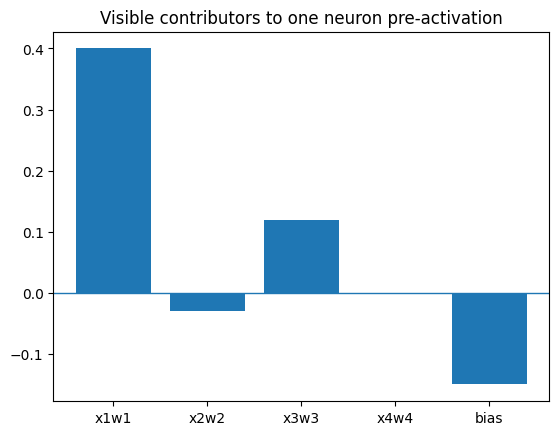

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([0.8, 0.1, 0.6, 0.0])
w = np.array([0.5, -0.3, 0.2, 0.7])
b = -0.15
contributions = x * w
z = contributions.sum() + b
print("x*w =", contributions)
print("sum(x*w)=", contributions.sum(), "bias=", b, "z=", z)
plt.bar(["x1w1", "x2w2", "x3w3", "x4w4", "bias"], [*contributions, b])
plt.axhline(0, linewidth=1)
plt.title("Visible contributors to one neuron pre-activation")
plt.show()

## Code walkthrough — instantiate the full TensorFlow / Keras architecture
The framework-specific model below still represents the same two affine transformations. Compare its parameter shapes against the manual matrix dimensions. The total parameter count is $784\times64+64+64\times10+10=50,890$.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

tf.random.set_seed(42)
from pathlib import Path
import urllib.request
import numpy as np
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
ARTIFACT_DIR = ROOT / "artifacts"
DATA_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)
MNIST_PATH = DATA_DIR / "mnist.npz"
MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"


def load_official_mnist():
    if not MNIST_PATH.exists():
        print("Downloading official MNIST archive to", MNIST_PATH)
        urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
    with np.load(MNIST_PATH) as data:
        return (data["x_train"], data["y_train"], data["x_test"], data["y_test"])


def balanced_subset(x, y, per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    selected = []
    for cls in range(10):
        candidates = np.flatnonzero(y == cls)
        selected.extend(rng.choice(candidates, size=per_class, replace=False))
    selected = np.asarray(selected)
    rng.shuffle(selected)
    return (x[selected], y[selected])


def prepare_splits():
    x_train_raw, y_train_raw, x_test_raw, y_test_raw = load_official_mnist()
    x_dev, y_dev = balanced_subset(x_train_raw, y_train_raw, per_class=600)
    x_test, y_test = balanced_subset(
        x_test_raw, y_test_raw, per_class=100, seed=SEED + 1
    )
    x_train, x_val, y_train, y_val = train_test_split(
        x_dev, y_dev, test_size=1000, random_state=SEED, stratify=y_dev
    )

    def transform(x):
        return x.reshape(len(x), -1).astype("float32") / 255.0

    return (
        transform(x_train),
        y_train,
        transform(x_val),
        y_val,
        transform(x_test),
        y_test,
    )


@tf.keras.utils.register_keras_serializable()
class MNISTMLP(tf.keras.Model):

    def __init__(self, hidden=64, **kwargs):
        super().__init__(**kwargs)
        self.hidden = hidden
        self.fc1 = tf.keras.layers.Dense(
            hidden, activation=None, kernel_initializer="he_normal"
        )
        self.act = tf.keras.layers.ReLU()
        self.fc2 = tf.keras.layers.Dense(
            10, activation=None, kernel_initializer="glorot_uniform"
        )

    def call(self, x, training=False):
        z1 = self.fc1(x)
        a1 = self.act(z1)
        logits = self.fc2(a1)
        return logits


model = MNISTMLP(hidden=64)
_ = model(tf.zeros((1, 784), dtype=tf.float32))
model.summary()
print("parameters", model.count_params())

2026-09-07 18:54:40.484765: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "mnistmlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (1, 64)                │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 10)                │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

parameters 50890


## Engineering inference
Width increases representational capacity but also memory, FLOPs and overfitting risk. Architecture is therefore both a statistical decision and a systems decision. Parameter count is the first bridge between mathematics and deployment cost.


### Interactive Plotly lab — clone + run locally

## Interactive neuron geometry: weights and bias reshape the affine surface

> **GitHub vs local behavior.** GitHub keeps the committed static plots, tables, metrics and explanations visible. **Clone this branch, create `environment.yml`, open the notebook in VS Code/Jupyter, select the Conda kernel, and run the cell below for full Plotly interactivity**: hover, zoom, pan, 3D rotation, legend selection, sliders and animation.

Rotate the 3D surface and move the parameter slider. The surface is the pre-activation $z=w_1x_1+w_2x_2+b$: weights change orientation while bias translates it. Hover exposes the exact numerical pre-activation at any input coordinate.

**Production/business interpretation.** The interaction is an inspection instrument, not decoration: change or inspect a technical quantity and connect it to model behavior, operational risk or downstream decision quality.


In [3]:
import os
import numpy as np
import plotly.graph_objects as go

grid = np.linspace(-2.0, 2.0, 55)
x1, x2 = np.meshgrid(grid, grid)
configs = [("w=(0.4,-0.8), b=0.1", 0.4, -0.8, 0.1), ("w=(1.0,-0.3), b=0.1", 1.0, -0.3, 0.1), ("w=(-0.6,0.9), b=-0.2", -0.6, 0.9, -0.2)]
surfaces = [w1 * x1 + w2 * x2 + b for _, w1, w2, b in configs]
fig = go.Figure(data=[go.Surface(x=x1, y=x2, z=surfaces[0], colorscale="Viridis", colorbar=dict(title="z = w·x + b"), hovertemplate="x1=%{x:.2f}<br>x2=%{y:.2f}<br>z=%{z:.3f}<extra></extra>")], frames=[go.Frame(name=str(i), data=[go.Surface(x=x1, y=x2, z=s, colorscale="Viridis", showscale=True)]) for i, s in enumerate(surfaces)])
fig.update_layout(title="Interactive affine neuron geometry", scene=dict(xaxis_title="input x1", yaxis_title="input x2", zaxis_title="pre-activation z"), sliders=[dict(currentvalue=dict(prefix="parameter setting: "), steps=[dict(label=label, method="animate", args=[[str(i)], dict(mode="immediate", frame=dict(duration=0), transition=dict(duration=0))]) for i, (label, *_rest) in enumerate(configs)])])
if os.getenv("GITHUB_ACTIONS") == "true":
    print("Interactive neuron surface built. Run locally to rotate, hover and move the parameter slider.")
else:
    fig.show(renderer="plotly_mimetype")


Interactive neuron surface built. Run locally to rotate, hover and move the parameter slider.
